## 5. Gene Embedding Analysis Tutorial

Uses **held-out test** embeddings from the new masking_split run
(`20260808_2325` / epoch=49, `context_mode=True`).

Paths are set in the config cell below. Extract already done — restart kernel and run all if paths look stale.


In this notebook, we explore gene embeddings as a framework for de novo gene program discovery. Genes grouped into the same program may represent coordinated biological functions and can serve as candidate targets for downstream perturbation studies.

We use the AnnData from Notebook 4:
- **cell embeddings** in `adata.obsm['cls_embeddings']`
- **gene embeddings** per LPS timepoint in `adata.varm` (`90m_LPS`, `6h_LPS`, `10h_LPS`)

This is the **test-split** extract (not the old full-data July 29 run).


Load the libraries

In [43]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

### Config — paths for this analysis

`EMB_H5AD` = Notebook 4 output (cell + gene embeddings).  
`FULL_H5AD` = LPS paired expression object (UMAP / expression viz).  
`GENE_NAME_ID_DICT` = Geneformer symbol↔Ensembl map (for readable gene names).


In [44]:
from pathlib import Path
import pickle
import scanpy as sc

WORKSPACE = Path("/home/stuke1/perturbgen")
SOD2 = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

# Notebook 4 extract: benchmark test-only output.
BENCHMARK_TAG = "paper_v1"
EMB_DIR = SOD2 / "T_perturb" / "res" / "masking_split" / f"embeddings_benchmark_test_{BENCHMARK_TAG}"
EMB_H5AD = EMB_DIR / f"benchmark_test_{BENCHMARK_TAG}_inference_embs.h5ad"

# Keep gene-program outputs under the same benchmark folder.
RESULTS_DIR = EMB_DIR / "gene_program_discovery"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# LPS expression AnnData (for optional expression UMAP / violin plots)
FULL_H5AD = (
    WORKSPACE
    / "T_perturb"
    / "tokenized_data"
    / "LPS_all_tps_2k"
    / "h5ad_pairing_2000_hvg_GF_genes"
    / "LPS_all_tps_2k.h5ad"
)

# Ensembl -> gene symbol (Geneformer)
GENE_NAME_ID_DICT = Path(
    "/mnt/sod2-project/csb4/stuke1/Geneformer/geneformer/gene_name_id_dict.pkl"
)

for p in (EMB_H5AD, FULL_H5AD, GENE_NAME_ID_DICT):
    assert Path(p).is_file(), f"missing: {p}"

print("EMB_DIR:", EMB_DIR)
print("EMB_H5AD:", EMB_H5AD)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIG_DIR:", FIG_DIR)
print("FULL_H5AD:", FULL_H5AD)
if (EMB_DIR / "ckpt_info.txt").is_file():
    print("--- ckpt_info ---")
    print((EMB_DIR / "ckpt_info.txt").read_text())

adata = sc.read(EMB_H5AD)
print(adata)
print("obsm:", list(adata.obsm.keys()), "| varm:", list(adata.varm.keys()))


EMB_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1
EMB_H5AD: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1/benchmark_test_paper_v1_inference_embs.h5ad
RESULTS_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1/gene_program_discovery
FIG_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1/gene_program_discovery/figures
FULL_H5AD: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_GF_genes/LPS_all_tps_2k.h5ad
--- ckpt_info ---
ckpt=/home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
split_path=/home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42

For each timepoint, the model provides gene embeddings stored in varm, while cell embeddings are available under cls_embeddings.

In [45]:
print(adata)
print("obsm keys:", list(adata.obsm.keys()))
print("varm keys:", list(adata.varm.keys()))

AnnData object with n_obs × n_vars = 26856 × 1856
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'
obsm keys: ['cls_embeddings']
varm keys: ['10h_LPS', '6h_LPS', '90m_LPS']


In [46]:
# Gene embeddings by timepoint
for tp in ["90m_LPS", "6h_LPS", "10h_LPS"]:
    g = adata.varm[tp]
    print(tp, g.shape)                     # (n_genes, d_model)
    print(g[:3, :8])                       # first 3 genes, first 8 dims               # first 3 cells, first 8 dims           # first 3 cells, first 8 dims

90m_LPS (1856, 768)
[[ 1.2179186e+00 -1.0690027e+00  1.0753286e-03 -2.5454995e-01
  -1.9380352e-03  2.7696180e-01  2.3489118e-02 -2.5053138e-01]
 [ 9.7140455e-01 -5.7773322e-01  1.1727896e-03  1.4461552e-01
  -1.9383859e-03  4.3857184e-01  1.8941617e-02 -1.0122437e-01]
 [ 1.0632974e+00 -6.4612645e-01  1.1904958e-03 -1.4604127e+00
  -1.9326147e-03  1.5154852e-01  7.7586859e-02 -1.1395487e+00]]
6h_LPS (1856, 768)
[[ 1.2816378e+00 -6.3596064e-01  1.0553986e-03 -9.3766159e-01
  -1.9390926e-03 -2.0176436e-01  8.2389964e-03 -1.6905968e-01]
 [ 8.0091244e-01 -8.5663252e-02  1.1655282e-03 -1.7952551e-01
  -1.9460309e-03  2.5088567e-01  1.2489688e-02 -3.9004400e-01]
 [ 1.0270165e+00 -7.4128342e-01  1.1820343e-03 -2.2109342e+00
  -1.9370132e-03 -1.0639584e-01  7.2558299e-02 -1.5440829e+00]]
10h_LPS (1856, 768)
[[ 1.4880710e+00 -9.4991434e-01  1.0605757e-03 -6.1904395e-01
  -1.9436359e-03 -3.6838636e-01  1.2897523e-02 -2.9503828e-01]
 [ 9.0770447e-01 -3.4335545e-01  1.1662130e-03  4.5143016e-02
  

Optionally, cell type labels are renamed for consistency. Cell embeddings can then be used for neighborhood graph construction and UMAP visualization.

In [47]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

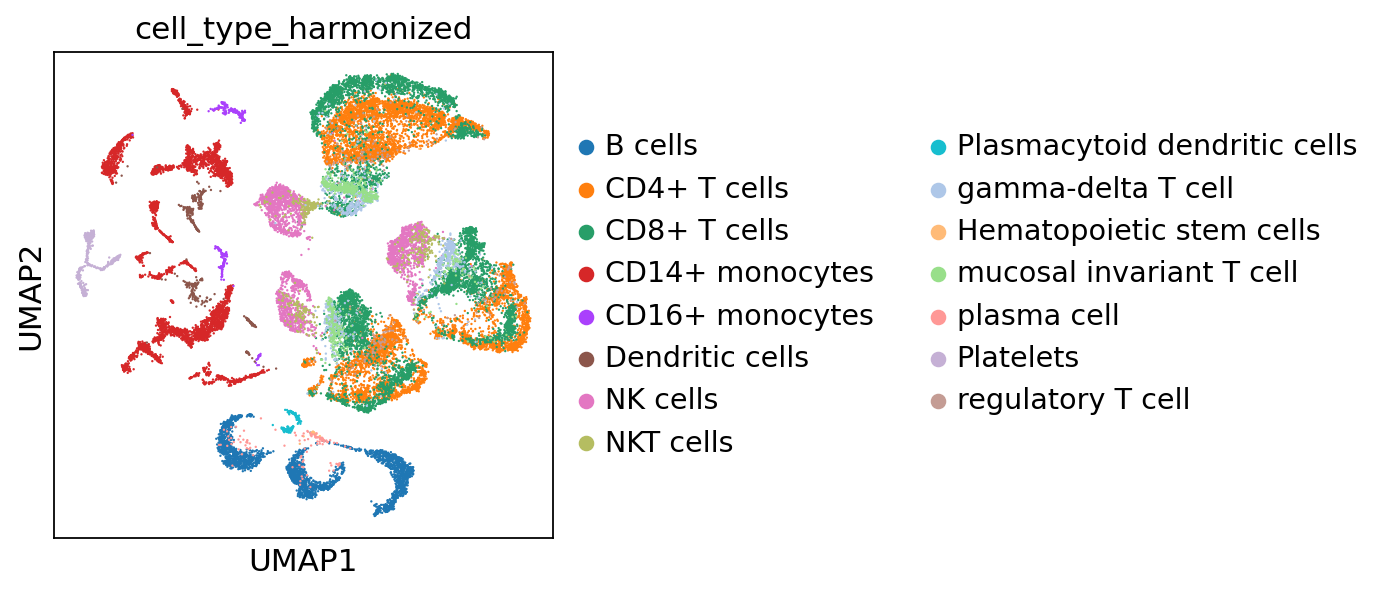

In [48]:
sc.pp.neighbors(adata,use_rep='cls_embeddings') # compute the neighborhood graph
sc.tl.umap(adata) # compute the UMAP coordinates
sc.pl.umap(adata,color='cell_type_harmonized') # plot the UMAP with cell type coloring

Load the LPS paired AnnData for (1) Ensembl→symbol mapping and (2) optional expression-space UMAP / program violin plots.


In [49]:
adata_full = sc.read(FULL_H5AD)
print(adata_full)
print("var columns:", list(adata_full.var.columns))


AnnData object with n_obs × n_vars = 223478 × 1856
    obs: 'patient_id', 'time_after_LPS', 'Sex', 'age', 'batch', 'IR_VJ_1_locus_tcr', 'IR_VJ_2_locus_tcr', 'IR_VDJ_1_locus_tcr', 'IR_VDJ_2_locus_tcr', 'IR_VJ_1_cdr3_tcr', 'IR_VJ_2_cdr3_tcr', 'IR_VDJ_1_cdr3_tcr', 'IR_VDJ_2_cdr3_tcr', 'IR_VJ_1_cdr3_nt_tcr', 'IR_VJ_2_cdr3_nt_tcr', 'IR_VDJ_1_cdr3_nt_tcr', 'IR_VDJ_2_cdr3_nt_tcr', 'IR_VJ_1_expr_tcr', 'IR_VJ_2_expr_tcr', 'IR_VDJ_1_expr_tcr', 'IR_VDJ_2_expr_tcr', 'IR_VJ_1_expr_raw_tcr', 'IR_VJ_2_expr_raw_tcr', 'IR_VDJ_1_expr_raw_tcr', 'IR_VDJ_2_expr_raw_tcr', 'IR_VJ_1_v_gene_tcr', 'IR_VJ_2_v_gene_tcr', 'IR_VDJ_1_v_gene_tcr', 'IR_VDJ_2_v_gene_tcr', 'IR_VJ_1_d_gene_tcr', 'IR_VJ_2_d_gene_tcr', 'IR_VDJ_1_d_gene_tcr', 'IR_VDJ_2_d_gene_tcr', 'IR_VJ_1_j_gene_tcr', 'IR_VJ_2_j_gene_tcr', 'IR_VDJ_1_j_gene_tcr', 'IR_VDJ_2_j_gene_tcr', 'IR_VJ_1_c_gene_tcr', 'IR_VJ_2_c_gene_tcr', 'IR_VDJ_1_c_gene_tcr', 'IR_VDJ_2_c_gene_tcr', 'IR_VJ_1_junction_ins_tcr', 'IR_VJ_2_junction_ins_tcr', 'IR_VDJ_1_junction_ins_tcr'

We normalize and log-transform the original AnnData object to generate a baseline UMAP visualization. This optional step serves primarily as a comparison to the UMAP derived from PerturbGen cell embeddings.

In [50]:
sc.pp.normalize_total(adata_full) # normalize the data
sc.pp.log1p(adata_full) # log-transform the data

In [ ]:
sc.pp.pca(adata_full)
sc.pp.neighbors(adata_full, use_rep="X_pca")
sc.tl.umap(adata_full)

In [ ]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata_full.obs['cell_type_harmonized'] = adata_full.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata_full.obs['cell_type_harmonized'].cat.categories}
)


In [ ]:
sc.set_figure_params(dpi_save=600) # set high dpi for saved figures

In [ ]:

mpl.rcParams.update({ # set global matplotlib parameters
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

sc.pl.umap( # plot UMAP of full data
    adata_full,
    color='cell_type_harmonized',
    frameon=False,
    save='_umapcelltype.png'  
)


In [ ]:
adata_full

Map Ensembl IDs in the embedding object to gene symbols via Geneformer's `gene_name_id_dict` (symbol→Ensembl), reversed.


In [ ]:
with open(GENE_NAME_ID_DICT, "rb") as f:
    symbol_to_ensembl = pickle.load(f)
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

adata.var["gene_symbol"] = [
    ensembl_to_symbol.get(g, g) for g in adata.var_names.astype(str)
]
n_sym = sum(1 for g, s in zip(adata.var_names, adata.var["gene_symbol"]) if g != s)
print(f"Mapped {n_sym}/{adata.n_vars} Ensembl IDs to gene symbols (embeddings)")

# Same mapping on expression AnnData (used later for score_genes)
if "ensembl_id" in adata_full.var.columns:
    full_ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    full_ids = adata_full.var["gene_ids-0"].astype(str)
else:
    full_ids = pd.Index(adata_full.var_names.astype(str))
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in full_ids]
n_full = sum(
    1 for g, s in zip(full_ids, adata_full.var["gene_symbol"]) if g != s
)
print(f"Mapped {n_full}/{adata_full.n_vars} Ensembl IDs to gene symbols (adata_full)")
adata.var[["gene_symbol"]].head()


We construct a new AnnData object in which each gene is treated as an observation (analogous to a cell), and its features correspond to a n(here =768)-dimensional learned embedding vector rather than expression values. This representation enables standard single-cell analysis workflows, such as UMAP visualization and clustering, to be directly applied to gene embeddings.

In [ ]:
gene_symbols = adata.var['gene_symbol'].values
timepoints = list(adata.varm.keys())

all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]  
    all_embeddings.append(embedding)
    
    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame({
    "gene_symbol": obs_genes,
    "timepoint": obs_timepoints
}, index=obs_names)

new_adata = ad.AnnData(X=X, obs=obs)

In [ ]:
new_adata.obs

Identify gene–timepoint vectors whose embedding values are all zero and report how many such cases exist.

In [ ]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")


In [ ]:
new_adata = new_adata[~zero_mask].copy() # Remove all-zero embeddings.

Now we calculate the neighbors and create a UMAP plot for the gene embeddings object.

In [ ]:
sc.pp.neighbors(new_adata) # compute the neighborhood graph
sc.tl.umap(new_adata) # compute the UMAP coordinates

In [ ]:
sc.pl.umap(new_adata,color='timepoint') # plot UMAP of gene embeddings colored by timepoint

Gene programs are identified by applying Leiden clustering to the gene embedding space, with each resulting cluster representing a coherent gene program.

In [ ]:
sc.tl.leiden(new_adata,resolution=1,key_added='r1') # cluster gene embeddings

In [ ]:
# Each color = one Leiden program (r1). Numbers in the legend are cluster ids, not ranks.
sc.pl.umap(
    new_adata,
    color="r1",
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    title="Test gene embeddings: Leiden clusters (r1)",
    frameon=False,
)

print("How many points in each cluster:")
print(new_adata.obs["r1"].astype(str).value_counts().sort_index())


For annotating gene programs, we recommend using predefined gene sets as guidance.


In [ ]:
results = {}

for cluster in new_adata.obs['r1'].unique():
    cluster_genes = new_adata.obs.loc[new_adata.obs['r1'] == cluster, 'gene_symbol'].tolist()
    
    enr = gp.enrichr( # perform gene set enrichment analysis
        gene_list=cluster_genes,
        gene_sets= ['GO_Biological_Process_2025','Reactome_Pathways_2024'],
        
        organism='Human',              
        outdir=None,                  
        cutoff=0.5                     
    )
    
    results[cluster] = enr.results.sort_values('Adjusted P-value').head(5) # store top 5 results per cluster

As an example, we annotate cluster 6 as cytokine signaling, since it contains many interleukins and chemokines. You can also calculate the z-score expression of any gene program of interest within the cell space.

In [ ]:
# Force adata_full.var_names -> gene symbols (match new_adata.obs['gene_symbol']).
# NOTE: this h5ad's gene_name column is still Ensembl IDs — always map via Geneformer dict.
if "ensembl_to_symbol" not in globals():
    with open(GENE_NAME_ID_DICT, "rb") as f:
        symbol_to_ensembl = pickle.load(f)
    ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

if "ensembl_id" in adata_full.var.columns:
    ids = adata_full.var["ensembl_id"].astype(str)
elif "gene_ids-0" in adata_full.var.columns:
    ids = adata_full.var["gene_ids-0"].astype(str)
else:
    ids = pd.Index(adata_full.var_names.astype(str))

adata_full.var["ensembl_id"] = ids.values
adata_full.var["gene_symbol"] = [ensembl_to_symbol.get(g, g) for g in ids]
adata_full.var_names = adata_full.var["gene_symbol"].astype(str).values
adata_full.var_names_make_unique()

n_mapped = int((~pd.Index(adata_full.var_names).str.startswith("ENSG")).sum())
print("adata_full var_names (symbols):", list(adata_full.var_names[:5]))
print(f"Non-Ensembl var_names: {n_mapped}/{adata_full.n_vars}")
assert n_mapped > 0, "Symbol mapping failed — check GENE_NAME_ID_DICT / ensembl_to_symbol"


In [ ]:
# Why cluster 6? Why IL1B / CXCL8 / ... ?
# Run this AFTER: new_adata, leiden (r1), and Enrichr (results = {}).

print("=" * 60)
print("1) WHO CHOSE 6?")
print("   The notebook author typed '6' in cluster_map. Leiden did not.")
print("   We only CHECK whether box 6 looks like cytokines in THIS run.")
print("=" * 60)

r1 = new_adata.obs["r1"].astype(str)
example_id = "6"
if example_id not in set(r1):
    example_id = sorted(set(r1), key=lambda x: int(x) if str(x).isdigit() else x)[0]
    print("Cluster 6 is missing in this run. Using", example_id, "instead.")

print("\nGenes sitting in box", example_id, "(first 15 unique):")
print(list(new_adata.obs.loc[r1 == example_id, "gene_symbol"].unique()[:15]))

key = next(k for k in results if str(k) == example_id)
print("\nEnrichr for box", example_id, "(this is the evidence for naming it):")
display(results[key].head(5))

print("\nOther boxes whose Enrichr text mentions cytokine/chemokine/interleukin:")
for cluster, df in results.items():
    if "Term" not in getattr(df, "columns", []):
        continue
    blob = " ".join(df["Term"].astype(str).str.lower())
    if any(w in blob for w in ["cytokine", "chemokine", "interleukin"]):
        top = str(df.iloc[0]["Term"]) if len(df) else ""
        mark = "  <-- tutorial uses this" if str(cluster) == "6" else ""
        print(f"  cluster {cluster}: {top}{mark}")

print("\n" + "=" * 60)
print("2) WHO CHOSE IL1B, CXCL8, ...?")
print("   Not Enrichr and not Leiden. The paper/tutorial highlight list")
print("   of famous LPS cytokine genes, to DRAW on the UMAP.")
print("=" * 60)

highlight_genes = ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R", "CXCL8", "CXCL3", "CXCL9"]
sub = new_adata.obs[new_adata.obs["gene_symbol"].str.upper().isin(highlight_genes)].copy()
sub["r1"] = sub["r1"].astype(str)
print("\nWhere those highlight genes actually landed (gene x time -> r1):")
display(sub[["gene_symbol", "timepoint", "r1"]].sort_values(["gene_symbol", "timepoint"]))
print("Count of highlight points per cluster:")
print(sub["r1"].value_counts())
in6 = sub.loc[sub["r1"] == "6", "gene_symbol"].str.upper().unique().tolist()
print("\nHighlight genes that ARE in box 6:", in6)
print("Highlight genes that are NOT in box 6:", sorted(set(highlight_genes) - set(in6)))


In [ ]:
# Score cluster 6 on expression space (var_names must be symbols — run cell above first)
genes_cluster_6 = list(
    dict.fromkeys(new_adata[new_adata.obs["r1"] == "6"].obs["gene_symbol"])
)
genes_present = [g for g in genes_cluster_6 if g in adata_full.var_names]

# Fallback: if var_names are still Ensembl, resolve symbols -> Ensembl
if not genes_present:
    if "symbol_to_ensembl" not in globals():
        with open(GENE_NAME_ID_DICT, "rb") as f:
            symbol_to_ensembl = pickle.load(f)
    genes_present = [
        symbol_to_ensembl[g]
        for g in genes_cluster_6
        if g in symbol_to_ensembl and symbol_to_ensembl[g] in adata_full.var_names
    ]

print(f"Cluster 6 genes in adata_full: {len(genes_present)}/{len(genes_cluster_6)}")
print("example cluster genes:", genes_cluster_6[:5])
print("example adata_full genes:", list(adata_full.var_names[:5]))
assert genes_present, (
    "No cluster genes found in adata_full — re-run the symbol-alignment cell above."
)

sc.tl.score_genes(
    adata_full, gene_list=genes_present, score_name="Cytokine Signaling"
)


In [ ]:
cluster_map = {
    '6': 'Cytokine Signaling',
}

new_adata.obs['MoA'] = new_adata.obs['r1'].map(cluster_map).fillna('Others') # annotate clusters with MoA labels

Visualize the UMAP and highlight the cluster containing the genes of interest.

In [ ]:
highlight_dict = {
    'Cytokine Signaling': ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R","CXCL8","CXCL3","CXCL9"],
}
custom_colors = {
    'Cytokine Signaling': '#d9db05',
    'Others': '#939da3',
}


umap_df = pd.DataFrame(new_adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['MoA']  = new_adata.obs['MoA'].astype(str).values          
umap_df['gene'] = new_adata.obs['gene_symbol'].astype(str).values  

present = sorted(umap_df['MoA'].unique())
palette = {k: custom_colors.get(k, '#939da3') for k in present}

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='MoA',
    palette=palette, linewidth=0, alpha=0.75, s=30
)
plt.title('UMAP with Annotated Genes', fontsize=30)
plt.xlabel('UMAP1', fontsize=24); plt.ylabel('UMAP2', fontsize=24)
plt.axis('off'); plt.grid(False)

texts = []
for moa, genes in highlight_dict.items():
    for gene in genes:
        mask = (umap_df['gene'].str.upper() == gene.upper()) & (umap_df['MoA'] == moa)
        if not mask.any():
            mask = (umap_df['gene'].str.upper() == gene.upper())

        if mask.any():
            plt.scatter(
                umap_df.loc[mask, 'UMAP1'],
                umap_df.loc[mask, 'UMAP2'],
                s=90, linewidths=0.7, edgecolors='k', facecolors='none', zorder=5
            )

            x_med = umap_df.loc[mask, 'UMAP1'].median()
            y_med = umap_df.loc[mask, 'UMAP2'].median()
            jitter_x = x_med - 1.0 if gene == "IL1RN" else x_med + np.random.uniform(-0.5, 0.5)
            jitter_y = y_med + np.random.uniform(-0.5, 0.5)

            texts.append(
                plt.text(jitter_x, jitter_y, gene,
                         fontsize=24, fontweight='bold', ha='center', va='center', zorder=6)
            )

adjust_text(
    texts,
    expand_points=(15, 15),
    expand_text=(10, 10),
    force_points=5.0,
    force_text=5.0,
    pad=10.0,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette[k], markersize=12) for k in present]
plt.legend(handles=handles, labels=present, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)

plt.tight_layout()
plt.savefig(FIG_DIR / "umap_highlight_gene_symbol.png", dpi=600, bbox_inches="tight")
plt.show()


Optionally, you may visualize the z-score expression of a gene program of interest, stratified by cell type or another relevant variable.

In [ ]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


df = adata_full.obs[['cell_type_harmonized', 'Cytokine Signaling']].dropna()

ordered_cell_types = (
    df.groupby('cell_type_harmonized')['Cytokine Signaling']
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)

data = [df.loc[df['cell_type_harmonized'] == ct, 'Cytokine Signaling'].values
        for ct in ordered_cell_types]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    data,
    patch_artist=True,  
    labels=ordered_cell_types,
    widths=0.7,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5)
)

for box in bp['boxes']:
    box.set_facecolor('peru')

ax.set_title('Cytokine Signaling')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "cytokine_signaling_boxplot.pdf", dpi=600, bbox_inches="tight", format="pdf")
plt.show()


We subset the data to the myeloid lineage, as the gene program was highly enriched in these cells. We then examined the gene program scores within the myeloid population across different timepoints.

In [ ]:
myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','CD16+ monocytes','Dendritic cells'])].copy()

In [ ]:
s = myeloids.obs['time_after_LPS'].astype('category')

rename_map = {
    '90m_LPS': '90m',
    '6h_LPS':  '6h',
    '10h_LPS': '10h',
    'normal':  'normal',
}
s = s.cat.rename_categories({k: v for k, v in rename_map.items() if k in s.cat.categories})

new_order = ['normal', '90m', '6h', '10h']
s = s.cat.reorder_categories(new_order, ordered=True)

myeloids.obs['time_after_LPS'] = s

palette = {
    'normal': '#d62728',
    '90m':    '#2ca02c',
    '6h':     '#1f77b4',
    '10h':    '#ff7f0e',
}
myeloids.uns['time_after_LPS_colors'] = [palette[c] for c in s.cat.categories]

In [ ]:
sc.pl.violin(myeloids,keys='Cytokine Signaling',groupby='time_after_LPS',rotation=45,save='myeloids.png') # plot violin plot of Cytokine Signaling score in myeloid cells